# People Analytics: Behavioral Risk Profiling & Attrition Prediction
## Phase 1 — Exploratory Analysis

**Author:** Washington Casamen Nolasco  
**Dataset:** IBM HR Analytics Employee Attrition & Performance  
**Last updated:** 2025

---

### Analytical purpose

This notebook does not aim to produce a predictive model — that comes in Phase 3. The goal here is to understand the **behavioral and organizational structure** of the data before making any modeling decisions.

We treat variables like `JobSatisfaction`, `WorkLifeBalance`, and `JobInvolvement` not as generic numeric features, but as **organizational attitude indicators** with construct-level meaning. Every analytical section is organized around a substantive organizational question, not a statistical procedure.

**Sections:**
1. Setup & data loading
2. Dataset overview & variable taxonomy
3. Target variable: attrition distribution and class imbalance
4. Psychometric-aligned variables: satisfaction, engagement, and workload
5. Career development and organizational tenure
6. Demographic and structural variables
7. Bivariate analysis: what correlates with attrition?
8. Key findings and implications for modeling

---
## 1. Setup & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

# Load data
df = pd.read_csv('../data/raw/HR-Employee-Attrition.csv')

# Drop constant columns — no analytical value
df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours'], inplace=True)

# Binary encode target
df['AttritionBinary'] = (df['Attrition'] == 'Yes').astype(int)

print(f'Dataset loaded: {df.shape[0]} employees, {df.shape[1]} variables')
df.head(3)

Dataset loaded: 1470 employees, 33 variables


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AttritionBinary
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,1,0,8,0,1,6,4,0,5,1
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,4,1,10,3,3,10,7,1,7,0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,2,0,7,3,3,0,0,0,0,1


---
## 2. Dataset Overview & Variable Taxonomy

Before any analysis, we classify variables by their **conceptual role** — not just their data type. This framing is deliberate: it reflects how an organizational psychologist or HR consultant would approach the data, distinguishing between attitudinal measures, structural descriptors, and outcome variables.

In [3]:
taxonomy = {
    'Target': ['Attrition'],
    'Psychometric — Satisfaction': ['JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction'],
    'Psychometric — Engagement': ['JobInvolvement', 'WorkLifeBalance'],
    'Workload & Strain': ['OverTime', 'BusinessTravel', 'DistanceFromHome'],
    'Career Development': ['YearsSinceLastPromotion', 'TrainingTimesLastYear', 'PercentSalaryHike', 'StockOptionLevel'],
    'Organizational Tenure': ['YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager', 'TotalWorkingYears'],
    'Compensation': ['MonthlyIncome', 'DailyRate', 'HourlyRate', 'MonthlyRate'],
    'Structural': ['Department', 'JobRole', 'JobLevel', 'BusinessTravel'],
    'Demographic': ['Age', 'Gender', 'MaritalStatus', 'EducationField', 'Education'],
    'Background': ['NumCompaniesWorked', 'PerformanceRating']
}

print('Variable taxonomy:\n')
for group, variables in taxonomy.items():
    print(f'  {group}:')
    for v in variables:
        print(f'    - {v}')
    print()

Variable taxonomy:

  Target:
    - Attrition

  Psychometric — Satisfaction:
    - JobSatisfaction
    - EnvironmentSatisfaction
    - RelationshipSatisfaction

  Psychometric — Engagement:
    - JobInvolvement
    - WorkLifeBalance

  Workload & Strain:
    - OverTime
    - BusinessTravel
    - DistanceFromHome

  Career Development:
    - YearsSinceLastPromotion
    - TrainingTimesLastYear
    - PercentSalaryHike
    - StockOptionLevel

  Organizational Tenure:
    - YearsAtCompany
    - YearsInCurrentRole
    - YearsWithCurrManager
    - TotalWorkingYears

  Compensation:
    - MonthlyIncome
    - DailyRate
    - HourlyRate
    - MonthlyRate

  Structural:
    - Department
    - JobRole
    - JobLevel
    - BusinessTravel

  Demographic:
    - Age
    - Gender
    - MaritalStatus
    - EducationField
    - Education

  Background:
    - NumCompaniesWorked
    - PerformanceRating



---
## 3. Target Variable: Attrition Distribution and Class Imbalance

Before modeling, we need to understand the structure of our outcome variable. A 16% attrition rate is not a data quality problem — it accurately reflects realistic organizational turnover. However, it creates a **class imbalance** that, if ignored, would bias any classifier toward predicting "No attrition" for everyone and still achieving ~84% accuracy.

We document this explicitly because it drives a key modeling decision: we will use `scale_pos_weight` in XGBoost rather than naive class balancing.

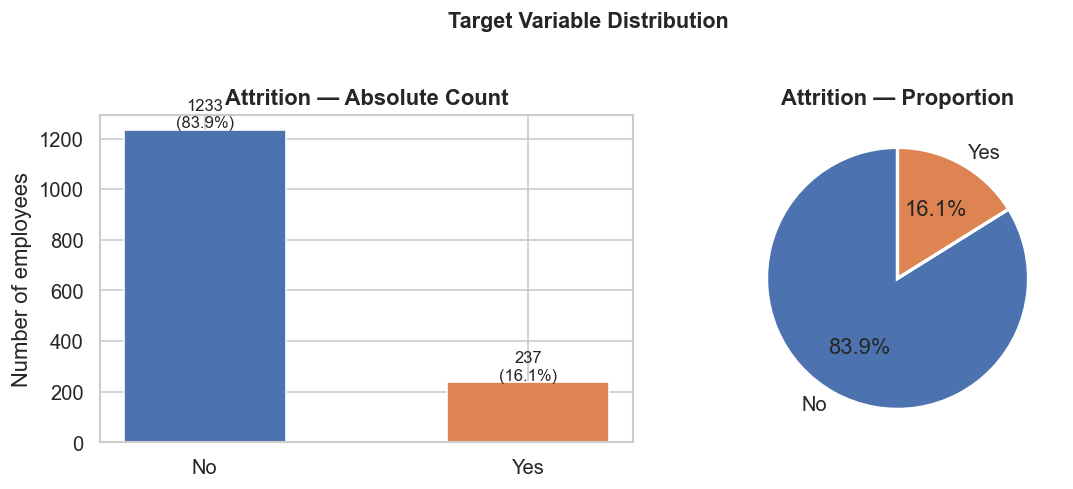

Class imbalance ratio (No/Yes): 5.20
Recommended scale_pos_weight for XGBoost: 5.20


In [6]:
attrition_counts = df['Attrition'].value_counts()
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
colors = ['#4C72B0', '#DD8452']
axes[0].bar(attrition_counts.index, attrition_counts.values, color=colors, width=0.5)
axes[0].set_title('Attrition — Absolute Count', fontweight='bold')
axes[0].set_ylabel('Number of employees')
for i, (val, pct) in enumerate(zip(attrition_counts.values, attrition_pct.values)):
    axes[0].text(i, val + 10, f'{val}\n({pct:.1f}%)', ha='center', fontsize=10)

# Pie chart
axes[1].pie(attrition_counts.values, labels=attrition_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Attrition — Proportion', fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/01_attrition_distribution.png')
plt.show()

imbalance_ratio = attrition_counts['No'] / attrition_counts['Yes']
print(f'Class imbalance ratio (No/Yes): {imbalance_ratio:.2f}')
print(f'Recommended scale_pos_weight for XGBoost: {imbalance_ratio:.2f}')

---
## 4. Psychometric-Aligned Variables: Satisfaction, Engagement, and Workload

These are the analytically most interesting variables in this dataset. They represent **latent organizational attitudes** measured on Likert-type scales (1–4), and they are the primary input for the behavioral segmentation in Phase 2.

Key question: **Do employees who leave show systematically different attitudinal profiles from those who stay?**

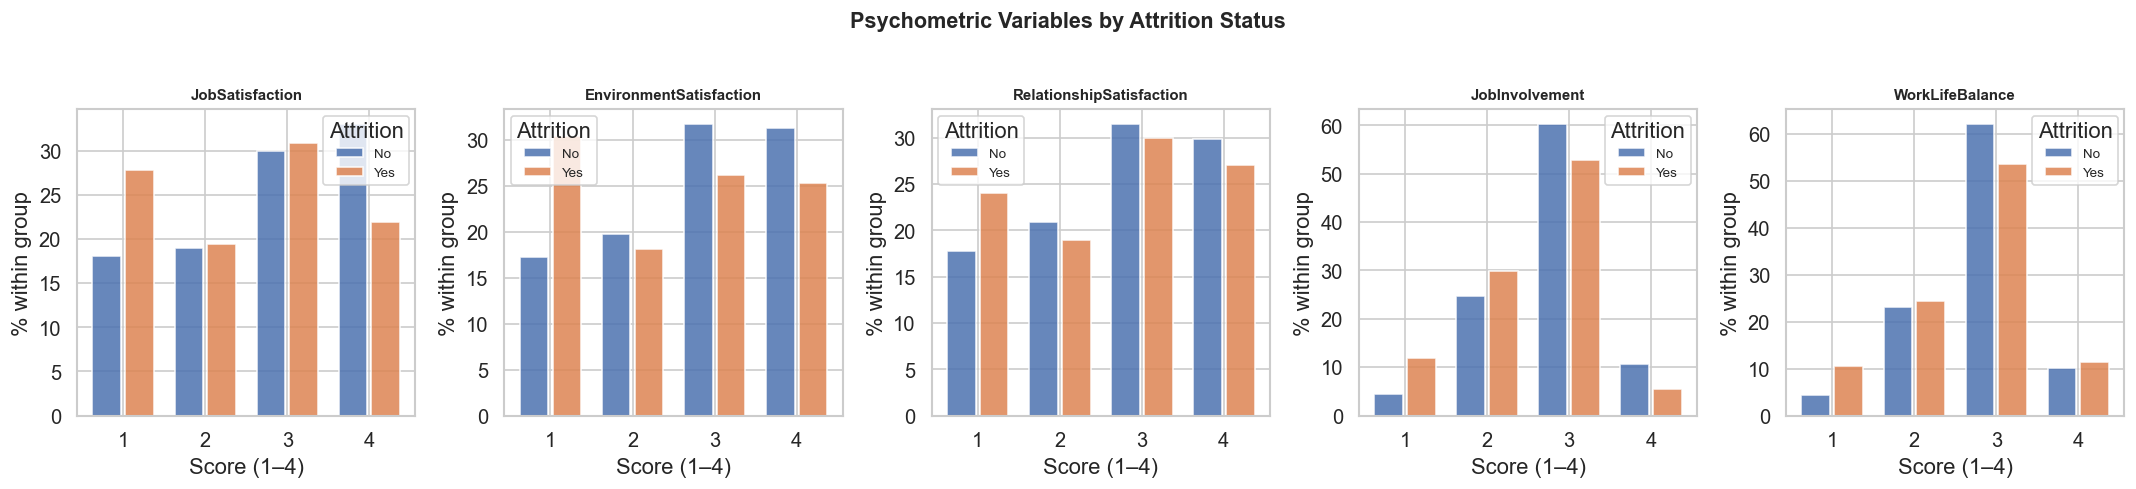

In [7]:
psychometric_vars = [
    'JobSatisfaction', 'EnvironmentSatisfaction',
    'RelationshipSatisfaction', 'JobInvolvement', 'WorkLifeBalance'
]

fig, axes = plt.subplots(1, len(psychometric_vars), figsize=(18, 4), sharey=False)

for ax, var in zip(axes, psychometric_vars):
    for label, color in zip(['No', 'Yes'], ['#4C72B0', '#DD8452']):
        subset = df[df['Attrition'] == label][var]
        counts = subset.value_counts().sort_index()
        pct = counts / counts.sum() * 100
        ax.bar([x + (0.2 if label == 'Yes' else -0.2) for x in pct.index],
               pct.values, width=0.35, label=label, color=color, alpha=0.85)
    ax.set_title(var, fontweight='bold', fontsize=9)
    ax.set_xlabel('Score (1–4)')
    ax.set_ylabel('% within group')
    ax.legend(title='Attrition', fontsize=8)
    ax.set_xticks([1, 2, 3, 4])

plt.suptitle('Psychometric Variables by Attrition Status', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/02_psychometric_by_attrition.png')
plt.show()

In [8]:
# Mean comparison table
mean_comparison = df.groupby('Attrition')[psychometric_vars].mean().round(2).T
mean_comparison['Difference (No - Yes)'] = (mean_comparison['No'] - mean_comparison['Yes']).round(2)
mean_comparison['Effect direction'] = mean_comparison['Difference (No - Yes)'].apply(
    lambda x: '↑ Higher in stayers' if x > 0.1 else ('↓ Higher in leavers' if x < -0.1 else '≈ Similar')
)
print('Mean scores by attrition status:\n')
mean_comparison

Mean scores by attrition status:



Attrition,No,Yes,Difference (No - Yes),Effect direction
JobSatisfaction,2.78,2.47,0.31,↑ Higher in stayers
EnvironmentSatisfaction,2.77,2.46,0.31,↑ Higher in stayers
RelationshipSatisfaction,2.73,2.60,0.13,↑ Higher in stayers
JobInvolvement,2.77,2.52,0.25,↑ Higher in stayers
WorkLifeBalance,2.78,2.66,0.12,↑ Higher in stayers


---
## 5. Workload & Strain: Overtime and Travel as Behavioral Risk Factors

Overtime and business travel are behavioral indicators of **work demand** — they reflect organizational conditions that employees experience, not personal attitudes. The question here is whether structural overload is a primary driver of attrition independently of attitudinal satisfaction.

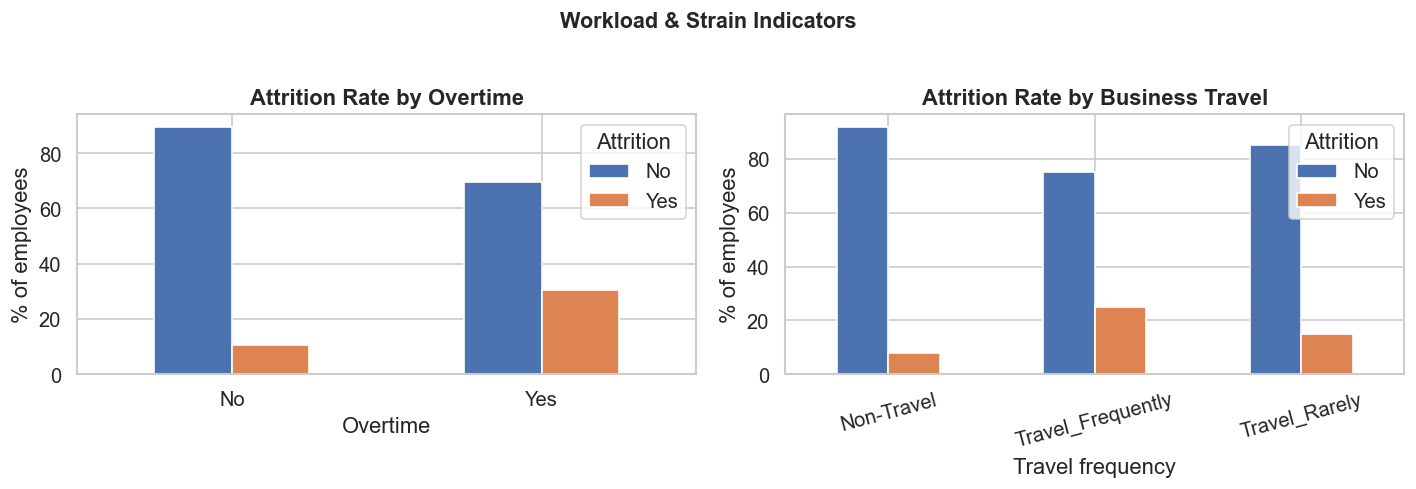

Attrition rate by overtime status:
OverTime
No     10.4
Yes    30.5


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overtime
overtime_attrition = df.groupby(['OverTime', 'Attrition']).size().unstack()
overtime_pct = overtime_attrition.div(overtime_attrition.sum(axis=1), axis=0) * 100
overtime_pct.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'],
                  edgecolor='white', width=0.5)
axes[0].set_title('Attrition Rate by Overtime', fontweight='bold')
axes[0].set_xlabel('Overtime')
axes[0].set_ylabel('% of employees')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Attrition')

# Business Travel
travel_attrition = df.groupby(['BusinessTravel', 'Attrition']).size().unstack()
travel_pct = travel_attrition.div(travel_attrition.sum(axis=1), axis=0) * 100
travel_pct.plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'],
                edgecolor='white', width=0.5)
axes[1].set_title('Attrition Rate by Business Travel', fontweight='bold')
axes[1].set_xlabel('Travel frequency')
axes[1].set_ylabel('% of employees')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)
axes[1].legend(title='Attrition')

plt.suptitle('Workload & Strain Indicators', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/03_workload_attrition.png')
plt.show()

# Overtime attrition rate
ot_rate = df.groupby('OverTime')['AttritionBinary'].mean() * 100
print('Attrition rate by overtime status:')
print(ot_rate.round(1).to_string())

---
## 6. Career Development and Organizational Tenure

Career stagnation — measured by time since last promotion, training frequency, and salary growth — is one of the most cited drivers of voluntary attrition in the organizational behavior literature. We examine whether this dataset reflects that pattern.

Key question: **Does attrition concentrate among employees with fewer development opportunities, or is it distributed across career stages?**

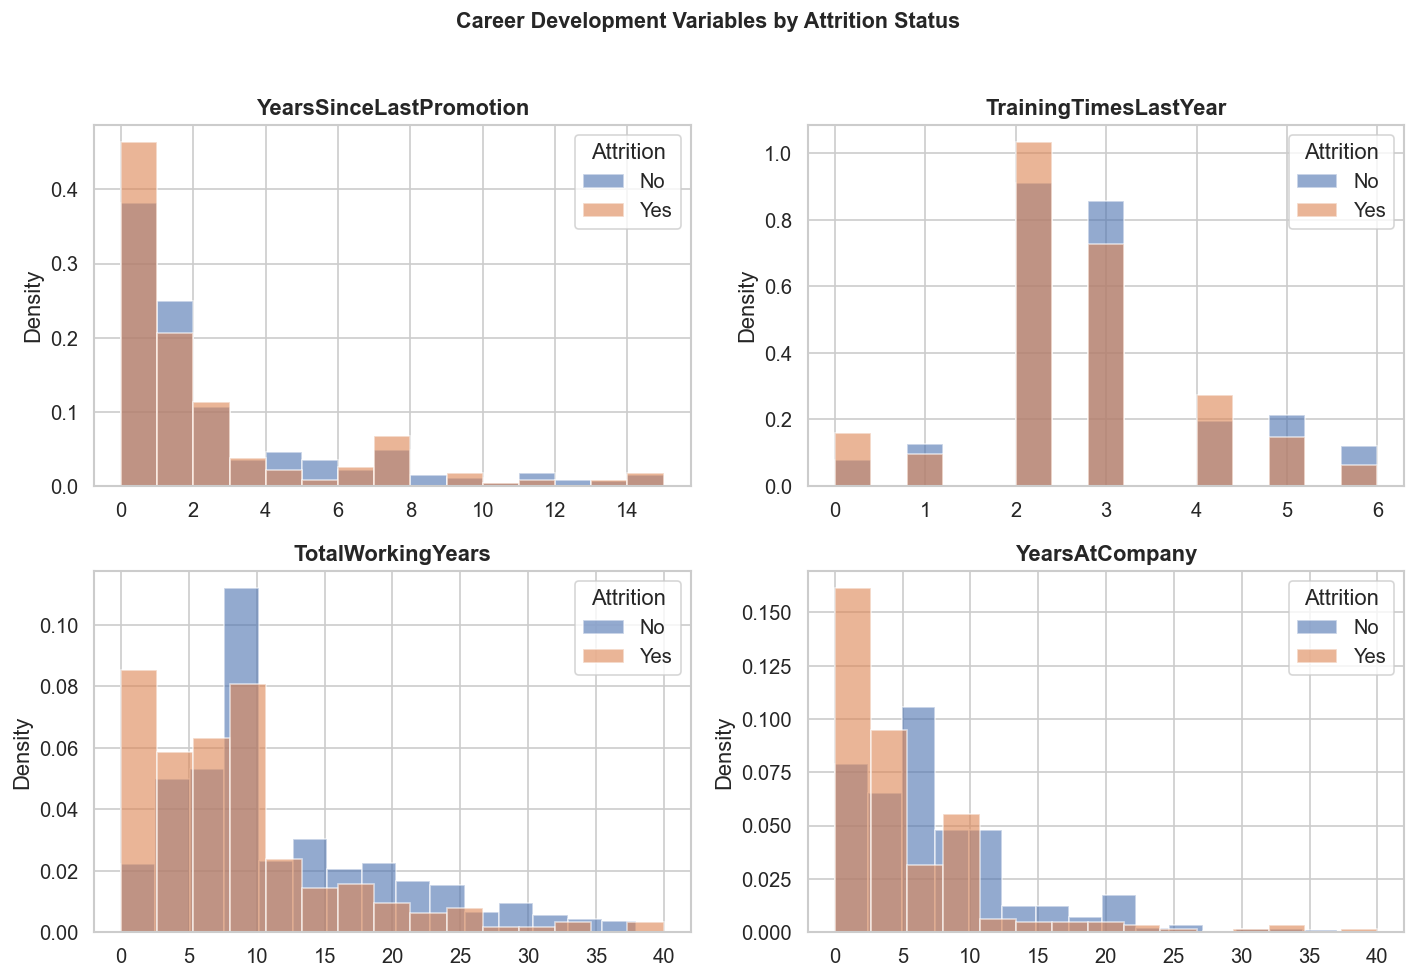

Mean values by attrition status:



,YearsSinceLastPromotion,TrainingTimesLastYear,TotalWorkingYears,YearsAtCompany
Attrition,,,,
No,2.23,2.83,11.86,7.37
Yes,1.95,2.62,8.24,5.13


In [10]:
career_vars = ['YearsSinceLastPromotion', 'TrainingTimesLastYear',
               'TotalWorkingYears', 'YearsAtCompany']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, var in zip(axes, career_vars):
    for label, color in zip(['No', 'Yes'], ['#4C72B0', '#DD8452']):
        subset = df[df['Attrition'] == label][var]
        ax.hist(subset, bins=15, alpha=0.6, color=color, label=label,
                density=True, edgecolor='white')
    ax.set_title(var, fontweight='bold')
    ax.set_ylabel('Density')
    ax.legend(title='Attrition')

plt.suptitle('Career Development Variables by Attrition Status', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/04_career_attrition.png')
plt.show()

# Summary statistics
print('Mean values by attrition status:\n')
df.groupby('Attrition')[career_vars].mean().round(2)

---
## 7. Bivariate Analysis: What Correlates with Attrition?

We compute point-biserial correlations between all numeric variables and the binary attrition outcome. This gives a ranked, quantitative view of which variables carry the most signal — and informs feature selection for Phase 3.

Note: correlation magnitude here is expected to be modest. Attrition is a complex, multicausal outcome. Variables with |r| > 0.15 are considered substantively relevant in organizational research.

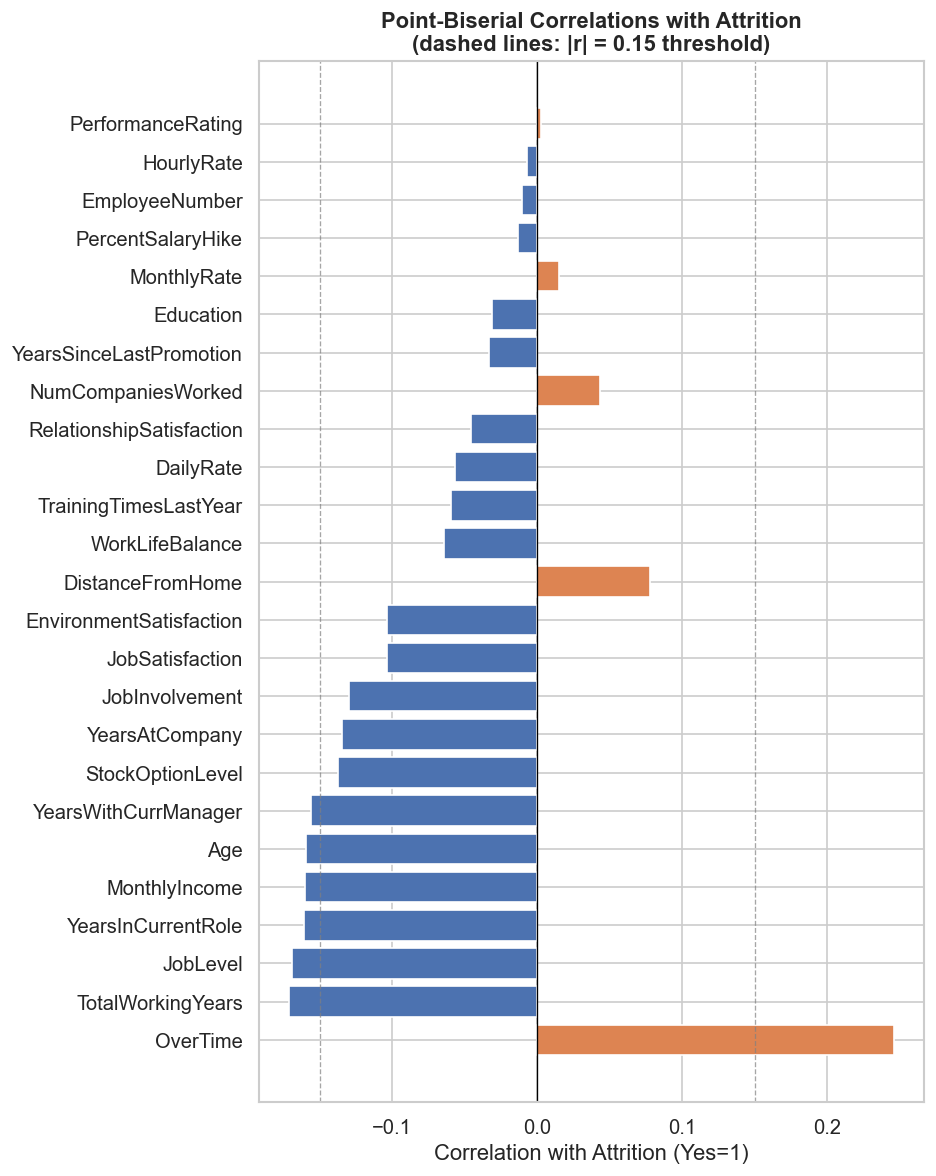

Top 10 variables by absolute correlation with attrition:
OverTime                0.246
TotalWorkingYears       0.171
JobLevel                0.169
YearsInCurrentRole      0.161
MonthlyIncome           0.160
Age                     0.159
YearsWithCurrManager    0.156
StockOptionLevel        0.137
YearsAtCompany          0.134
JobInvolvement          0.130


In [11]:
# Encode categorical variables for correlation
df_encoded = df.copy()
df_encoded['OverTime'] = (df_encoded['OverTime'] == 'Yes').astype(int)

numeric_cols = df_encoded.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'AttritionBinary']

correlations = df_encoded[numeric_cols].corrwith(df_encoded['AttritionBinary'])
correlations = correlations.sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 10))
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in correlations.values]
ax.barh(correlations.index, correlations.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(0.15, color='gray', linewidth=0.8, linestyle='--', alpha=0.7)
ax.axvline(-0.15, color='gray', linewidth=0.8, linestyle='--', alpha=0.7)
ax.set_title('Point-Biserial Correlations with Attrition\n(dashed lines: |r| = 0.15 threshold)',
             fontweight='bold')
ax.set_xlabel('Correlation with Attrition (Yes=1)')
plt.tight_layout()
plt.savefig('../reports/figures/05_correlations_attrition.png')
plt.show()

print('Top 10 variables by absolute correlation with attrition:')
print(correlations.abs().sort_values(ascending=False).head(10).round(3).to_string())

---
## 8. Key Findings and Implications for Modeling

This section synthesizes the exploratory findings into actionable conclusions for the next phases of the pipeline.

In [12]:
findings = {
    'Class imbalance': [
        f'Attrition rate: {df["AttritionBinary"].mean()*100:.1f}%',
        f'Imbalance ratio (No/Yes): {imbalance_ratio:.2f}',
        'Action: use scale_pos_weight in XGBoost, evaluate with F1/AUC not accuracy'
    ],
    'Top behavioral signals': [
        'OverTime is the strongest single binary predictor',
        'JobSatisfaction and EnvironmentSatisfaction show clear mean differences by attrition',
        'TotalWorkingYears and YearsAtCompany: leavers are earlier in career trajectory'
    ],
    'Clustering candidates': [
        'Psychometric block (5 variables) forms the core segmentation space',
        'Add OverTime, BusinessTravel as behavioral strain indicators',
        'Expected: 3-4 interpretable behavioral profiles'
    ],
    'Modeling decisions': [
        'XGBoost with scale_pos_weight for prediction',
        'SHAP values computed globally and per cluster',
        'Evaluation metrics: AUC-ROC, F1 (minority class), Precision-Recall curve'
    ]
}

for section, points in findings.items():
    print(f'\n{section.upper()}')
    print('-' * 40)
    for point in points:
        print(f'  • {point}')


CLASS IMBALANCE
----------------------------------------
  • Attrition rate: 16.1%
  • Imbalance ratio (No/Yes): 5.20
  • Action: use scale_pos_weight in XGBoost, evaluate with F1/AUC not accuracy

TOP BEHAVIORAL SIGNALS
----------------------------------------
  • OverTime is the strongest single binary predictor
  • JobSatisfaction and EnvironmentSatisfaction show clear mean differences by attrition
  • TotalWorkingYears and YearsAtCompany: leavers are earlier in career trajectory

CLUSTERING CANDIDATES
----------------------------------------
  • Psychometric block (5 variables) forms the core segmentation space
  • Add OverTime, BusinessTravel as behavioral strain indicators
  • Expected: 3-4 interpretable behavioral profiles

MODELING DECISIONS
----------------------------------------
  • XGBoost with scale_pos_weight for prediction
  • SHAP values computed globally and per cluster
  • Evaluation metrics: AUC-ROC, F1 (minority class), Precision-Recall curve


---

**Next:** Phase 2 — Behavioral Segmentation (`src/clustering.py` + visualization)  
**Then:** Phase 3 — Interpretable Prediction with XGBoost + SHAP  
**Finally:** Phase 4 — Streamlit Dashboard